In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import ast
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# To remove warnings
import warnings
warnings.filterwarnings('ignore')

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/zomato-bangalore-restaurants/zomato.csv


In [30]:
data = pd.read_csv('/kaggle/input/zomato-bangalore-restaurants/zomato.csv')

In [31]:
data.head(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Data Description
- ****url****: Contains the url of the restaurant in the zomato website
- ****address****: contains the address of the restaurant in Bengaluru
- ****name****: contains the name of the restaurant
- ****online_order****: whether online ordering is available in the restaurant or not
- ****book_table****: table book option available or not
- ****rate****: contains the overall rating of the restaurant out of 5
- ****votes****: contains total number of rating for the restaurant as of the above mentioned date
- ****phone****: contains the phone number of the restaurant
- ****location****: contains the neighborhood in which the restaurant is located
- ****rest_type****: restaurant type like quick bites or casual dining
- ****dish_liked****: dishes people liked in the restaurant
- ****cuisines****: food styles, separated by comma
- ****approx_cost(for two people)****: contains the approximate cost for meal for two people
- ****reviews_list****: list of tuples containing reviews for the restaurant, each tuple consists of two values, rating and review by the customer
- ****menu_item****: contains list of menus available in the restaurant
- ****listed_in(type)****: type of meal
- ****listed_in(city)****: contains the neighborhood in which the restaurant is listed

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

# Missing data Information
- ****rate****: 43942 non-null / ****15.03%**** missing data - This coulmn gives the rating given to a restaurant. I think ****ignoring this column**** will be best as imputing it with another value might undervalue or overvalue the rating of a restaurant.
- ****phone****: 50509 non-null / ****2.33%**** missing data - Ignore, the missing data is ****less than 10%****
- ****location****: 51696 non-null / ****0.04%**** missing data - Ignore, the missing data is ****less than 10%****
- ****rest_type****: 51490 non-null / ****0.43%**** misssing data - Ignore, the missing data is ****less than 10%****
- ****dish_liked****: 23639 non-null / ****54.29%**** missing data - This column gives the most liked dish of the restaurant. I can't impute this field as each restaurant is unique and serves different food. ****Ignoring this column**** as well.
- ****cuisines****: 51672 non-null / ****0.08%**** missing data - Ignore, the missing data is ****less than 10%****
- ****approx_cost(for two people)****: 51371 non-null / ****0.67%**** missing data - Ignore, the missing data is ****less than 10%****

# Formatting Data

In [33]:
# Coverting Object to Numeric and formatting (Run this cell only one time only)
data["rate"] = pd.to_numeric(data["rate"].str.split('/').str[0], errors='coerce')
data["approx_cost(for two people)"] = pd.to_numeric(data["approx_cost(for two people)"], errors='coerce')

In [34]:
# Formatting phone column (Run this cell only one time only)
data["phone"] = data["phone"].str.split(r'\r\n')
data["phone"] = data["phone"].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

In [35]:
# Formatting menu_item column (Run this cell only one time only)
data["menu_item"] = data["menu_item"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
data["menu_item"] = data["menu_item"].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
data["menu_item"] = data["menu_item"].replace('', np.nan) # Replacing empty string with NaN

In [36]:
# Formatting reviews_list column (Run this cell only one time only)
def clean_reviews(raw_text):
    try:
        # Step 1: Remove outer quotes if present
        if isinstance(raw_text, str) and raw_text.startswith("'") and raw_text.endswith("'"):
            raw_text = raw_text[1:-1]

        # Step 2: Try parsing with ast.literal_eval
        parsed = ast.literal_eval(raw_text)

        entries = []
        for rating, review in parsed:
            # Clean unwanted text
            review = review.replace("RATED\\n", "").replace("RATED\n", "").replace("\\n", "\n").strip()
            # Try fixing unicode junk
            try:
                review = bytes(review, "utf-8").decode("utf-8", "ignore")
            except:
                pass
            entries.append(f"{rating}: {review}")

        return "\n\n".join(entries)

    except Exception as e:
        print("⚠️ Parsing error:", e)
        print("Problematic input snippet:", raw_text[:200])  # Show first 200 chars
        return ""

# Apply to your DataFrame
data['reviews_list'] = data['reviews_list'].apply(clean_reviews)


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51717 non-null  object 
 1   address                      51717 non-null  object 
 2   name                         51717 non-null  object 
 3   online_order                 51717 non-null  object 
 4   book_table                   51717 non-null  object 
 5   rate                         41665 non-null  float64
 6   votes                        51717 non-null  int64  
 7   phone                        50509 non-null  object 
 8   location                     51696 non-null  object 
 9   rest_type                    51490 non-null  object 
 10  dish_liked                   23639 non-null  object 
 11  cuisines                     51672 non-null  object 
 12  approx_cost(for two people)  44454 non-null  float64
 13  reviews_list    

## After Formatting
- ****menu_item****: 12100 non-null / ****76.6%**** missing data - This column gives menu items so we should be ignoring this but needs to be deleted when using some predictive models.

In [38]:
data.head(10)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,"080 42297555, +91 9743772233",Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Rated 4.0: A beautiful place to dine in.The in...,NaN,Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Rated 4.0: Had been here for dinner with famil...,NaN,Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Rated 3.0: Ambience is not that good enough an...,NaN,Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Rated 4.0: Great food and proper Karnataka sty...,NaN,Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,"+91 8026612447, +91 9901210005",Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Rated 4.0: Very good restaurant in neighbourho...,NaN,Buffet,Banashankari
5,https://www.zomato.com/bangalore/timepass-dinn...,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,Yes,No,3.8,286,"+91 9980040002, +91 9980063005",Basavanagudi,Casual Dining,"Onion Rings, Pasta, Kadhai Paneer, Salads, Sal...",North Indian,600.0,Rated 3.0: Food 3/5\nAmbience 3/5\nService 3/5...,NaN,Buffet,Banashankari
6,https://www.zomato.com/bangalore/rosewood-inte...,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,No,No,3.6,8,"+91 9731716688, 080 26740366",Mysore Road,Casual Dining,NaN,"North Indian, South Indian, Andhra, Chinese",800.0,Rated 5.0: Awesome food ??Great serviceFriendl...,NaN,Buffet,Banashankari
7,https://www.zomato.com/bangalore/onesta-banash...,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,Yes,Yes,4.6,2556,"080 48653961, 080 48655715",Banashankari,"Casual Dining, Cafe","Farmhouse Pizza, Chocolate Banana, Virgin Moji...","Pizza, Cafe, Italian",600.0,Rated 5.0: I personally really liked this plac...,NaN,Cafes,Banashankari
8,https://www.zomato.com/bangalore/penthouse-caf...,"1, 30th Main Road, 3rd Stage, Banashankari, Ba...",Penthouse Cafe,Yes,No,4.0,324,"+91 8884135549, +91 9449449316",Banashankari,Cafe,"Pizza, Mocktails, Coffee, Nachos, Salad, Pasta...","Cafe, Italian, Continental",700.0,Rated 3.0: I had been to this place with one o...,NaN,Cafes,Banashankari
9,https://www.zomato.com/bangalore/smacznego-ban...,"2470, 21 Main Road, 25th Cross, Banashankari, ...",Smacznego,Yes,No,4.2,504,"+91 9945230807, +91 9743804471",Banashankari,Cafe,"Waffles, Pasta, Coleslaw Sandwich, Choco Waffl...","Cafe, Mexican, Italian, Momos, Beverages",550.0,Rated 4.0: Easy to locate\nVFM 3.5/5\nTaste 5/...,NaN,Cafes,Banashankari


Now the data looks cleaner. Let's perform some visualization :)

# Visualization

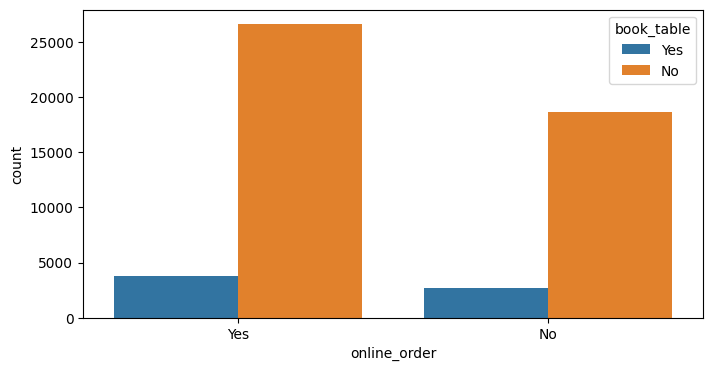

In [39]:
plt.figure(figsize=(8, 4))
sns.countplot(x = "online_order", hue = "book_table", data = data);

There are around 20,000 restaurants not taking online orders and no table booking available. Need to look into why these restaurant are not taking online orders? Is it due to technology illiteracy?

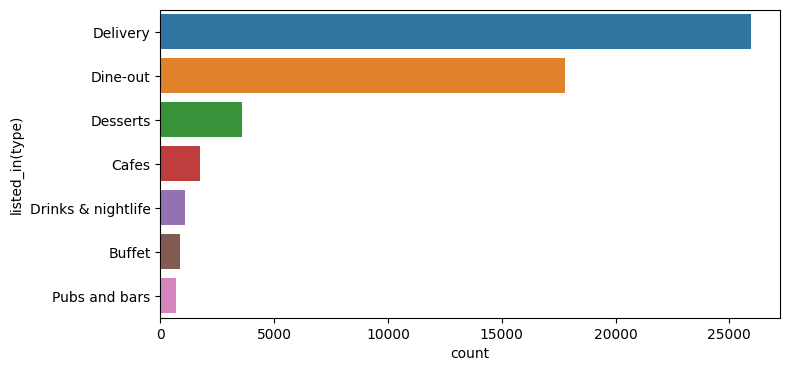

In [40]:
plt.figure(figsize=(8, 4))
sns.countplot(y = "listed_in(type)", order = data["listed_in(type)"].value_counts().index, data = data);

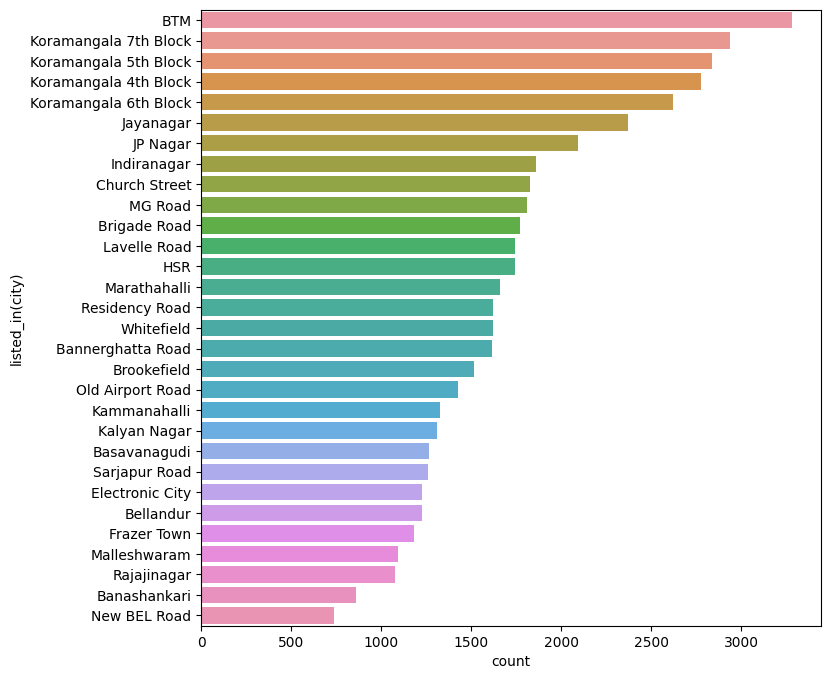

In [41]:
plt.figure(figsize=(8, 8))
sns.countplot(y = "listed_in(city)", order = data["listed_in(city)"].value_counts().index, data = data);

<Axes: ylabel='approx_cost(for two people)'>

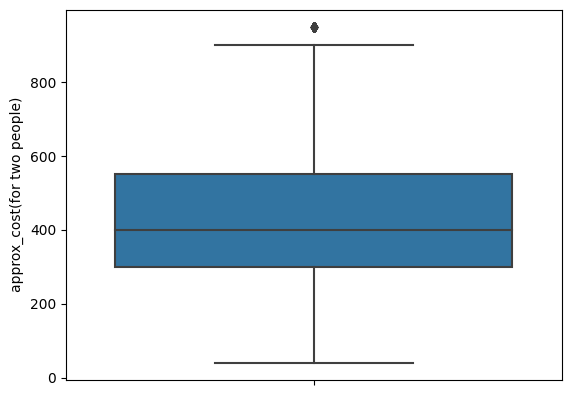

In [42]:
sns.boxplot(y = "approx_cost(for two people)", data = data)